

# EDA on Real, Scraped Data - Massachusetts Income by County
### OPIM 5641 - Business Decision Modeling · Module 1.1

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5641-notebooks/blob/main/1_EDA_Intro/EDA_Wikipedia_Income.ipynb)

*Run me top to bottom - **Runtime → Run all**. The data comes straight from Wikipedia, so there's nothing to upload.*

## M1.1 V2
Completed On your own answers. The short explanations below use the results shown in this notebook. These Wikipedia tables use different years, so the state comparison is only a basic comparison of the listed data.

Before we can optimize anything, we need to understand our data - and the fastest way to learn EDA is on data you actually scraped yourself. In this notebook we grab a real table off Wikipedia - **income statistics for every county in Massachusetts** - clean it up, map it, and squeeze some insight out of it. Then we scale the exact same code to six states with a for loop. This is the loop you will repeat all semester: **question → load → clean → describe → visualize → insight**.

🔷 **The nugget:** real data never arrives clean. The two "problems" we hit in this notebook - a website that blocks naive scrapers, and **phantom rows** (a whole-state row and a United States row hiding inside the county table) - are not annoyances, they ARE the job.

## Data sources - the Wikipedia pages we scrape
All free, all public - open a couple in another tab so you can see exactly what we're scraping. On every page we use the **county summary table** (income by county):

- [Massachusetts locations by per capita income](https://en.wikipedia.org/wiki/List_of_Massachusetts_locations_by_per_capita_income) - our main dataset
- [Connecticut locations by per capita income](https://en.wikipedia.org/wiki/List_of_Connecticut_locations_by_per_capita_income) - the "Apply to Connecticut" section
- [New Hampshire locations by per capita income](https://en.wikipedia.org/wiki/List_of_New_Hampshire_locations_by_per_capita_income)
- [New York locations by per capita income](https://en.wikipedia.org/wiki/List_of_New_York_locations_by_per_capita_income)
- [Vermont locations by per capita income](https://en.wikipedia.org/wiki/List_of_Vermont_locations_by_per_capita_income)
- [Rhode Island locations by per capita income](https://en.wikipedia.org/wiki/List_of_Rhode_Island_locations_by_per_capita_income)

*(the last four feed the six-state for-loop finale)* · County boundaries come from the [Census Bureau cartographic boundary files](https://www2.census.gov/geo/tiger/GENZ2022/shp/) (`cb_2022_us_county_500k.zip`).

# Step 1: Scrape the table from Wikipedia
Once upon a time you could just call `pd.read_html(url)` and be done. Try it - it fails now with `HTTP Error 403: Forbidden`. Wikipedia sees a request with no browser "User-Agent" and assumes you are a bot (fair!).

**Remember:** a 403 is the server saying "I see you, and no." It is not a bug in pandas.

In [1]:
# import our libraries - every line has a comment, that's the house style!
import pandas as pd               # tables
import requests                   # fetching web pages politely
import io                         # wrapping text so read_html can parse it
import matplotlib.pyplot as plt   # plots

In [2]:
# the page we want to scrape
url = 'https://en.wikipedia.org/wiki/List_of_Massachusetts_locations_by_per_capita_income'

# this used to work... now it throws HTTP Error 403: Forbidden. Uncomment and see for yourself!
# df = pd.read_html(url)[1]

The fix is simple and it is a real-world lesson: fetch the page yourself with a **User-Agent header** (telling the server who you are), then hand the HTML text to `pd.read_html()`.

In [3]:
# fetch the page with a User-Agent header - now Wikipedia is happy to talk to us
response = requests.get(url, headers={'User-Agent': 'Mozilla/5.0 (OPIM 5641 teaching demo)'})
print(response.status_code)   # 200 means OK!

200


In [4]:
# parse ALL the tables on the page from the HTML we already downloaded
tables = pd.read_html(io.StringIO(response.text))

# how many tables did we get? which one is ours?
for i, t in enumerate(tables):
    print(i, t.shape)

0 (6, 1)
1 (16, 8)
2 (341, 9)
3 (5, 2)
4 (7, 2)


Table index 1 is the **county summary table** - that's ours. Grabbing the right table by index is part of scraping; always look before you leap.

**On your own:** what is table index 2? Print it and figure out what it represents.

In [5]:
# grab the county summary table
df = tables[1]
df

,State Rank,US Rank,County,Per capita income,Median household income,Median family income,Population,Number of households
0,1.0,25.0,Norfolk,"$46,920","$84,916","$108,943",677296.0,257451.0
1,2.0,30.0,Middlesex,"$42,861","$82,090","$104,032",1522533.0,581120.0
2,3.0,102.0,Barnstable,"$36,142","$60,526","$76,311",215449.0,95398.0
3,NaN,NaN,Massachusetts,"$35,763","$66,866","$84,900",6605058.0,2530147.0
4,4.0,115.0,Plymouth,"$35,220","$75,092","$90,431",497386.0,179617.0
5,5.0,117.0,Essex,"$35,167","$67,311","$84,185",750808.0,286008.0
6,6.0,164.0,Dukes,"$33,363","$66,288","$82,452",16739.0,5891.0
7,7.0,193.0,Suffolk,"$32,835","$53,540","$61,449",735701.0,288240.0
8,8.0,244.0,Worcester,"$31,537","$65,223","$81,519",802688.0,299663.0
9,9.0,365.0,Hampshire,"$29,460","$61,227","$81,385",159267.0,58828.0


In [6]:
# keep the city and town table separate from the county data
towns = tables[2]
towns

,Rank,Municipality,Type,County,Per capita income,Median household income,Median family income,Households,Population
0,1,Dover,Town,Norfolk,"$138,720","$250,000+","$250,000+",1916,5894
1,2,Weston,Town,Middlesex,"$131,707","$250,000+","$250,000+",3532,11827
2,3,Wellesley,Town,Norfolk,"$113,079","$250,000+","$250,000+",8668,29365
3,4,Sherborn,Town,Middlesex,"$110,567","$240,000+","$250,000+",1515,4406
4,5,Carlisle,Town,Middlesex,"$110,381","$250,000+","$250,000+",1800,5215
...,...,...,...,...,...,...,...,...,...
336,337,New Bedford,City,Bristol,"$42,088","$56,052","$69,567",41395,100309
337,338,Amherst,City,Hampshire,"$42,080","$65,938","$136,949",9328,39416
338,339,Holyoke,City,Hampden,"$42,067","$51,892","$65,381",15062,38480
339,340,Lawrence,City,Essex,"$42,055","$57,903","$86,600",30291,87798


**My answer:** Table index 2 ranks Massachusetts cities and towns by per capita income (2021 USD). Each row is a city or town, not a county.

# Step 2: Clean the scrape
Two traps are waiting in this table, and both will quietly wreck your analysis if you miss them.

## Trap 1 - phantom rows
Count the rows: **16**. But Massachusetts has **14 counties**. Wikipedia sneaks in a **whole-state row** (*Massachusetts*), a **United States row**, and a blank row - summary lines that are NOT counties. Let's catch them red-handed:

In [7]:
# BEFORE: highlight the intruders in red - notice they have no State Rank, because they aren't counties
phantom = df['County'].isin(['Massachusetts', 'United States']) | df['County'].isna()
df.style.apply(lambda row: ['background-color: #FFC7CE' if phantom[row.name] else '' for _ in row], axis=1)

,State Rank,US Rank,County,Per capita income,Median household income,Median family income,Population,Number of households
0,1.000000,25.000000,Norfolk,"$46,920","$84,916","$108,943",677296.000000,257451.000000
1,2.000000,30.000000,Middlesex,"$42,861","$82,090","$104,032",1522533.000000,581120.000000
2,3.000000,102.000000,Barnstable,"$36,142","$60,526","$76,311",215449.000000,95398.000000
3,nan,nan,Massachusetts,"$35,763","$66,866","$84,900",6605058.000000,2530147.000000
4,4.000000,115.000000,Plymouth,"$35,220","$75,092","$90,431",497386.000000,179617.000000
5,5.000000,117.000000,Essex,"$35,167","$67,311","$84,185",750808.000000,286008.000000
6,6.000000,164.000000,Dukes,"$33,363","$66,288","$82,452",16739.000000,5891.000000
7,7.000000,193.000000,Suffolk,"$32,835","$53,540","$61,449",735701.000000,288240.000000
8,8.000000,244.000000,Worcester,"$31,537","$65,223","$81,519",802688.000000,299663.000000
9,9.000000,365.000000,Hampshire,"$29,460","$61,227","$81,385",159267.000000,58828.000000


In [8]:
# watch the phantom rows skew the stats - Population max should be Middlesex (~1.5M)
df['Population'].describe() # max is 311 MILLION... that's the United States row!

count    1.500000e+01
mean     2.164910e+07
std      8.021124e+07
min      1.673900e+04
25%      1.873580e+05
50%      5.498700e+05
75%      7.767480e+05
max      3.115366e+08
Name: Population, dtype: float64

In [9]:
# the fix: drop the blank row, then drop the state and national rows by name
df = df.dropna(subset=['County'])
df = df[~df['County'].isin(['Massachusetts', 'United States'])]
print(len(df), 'real county rows now')

# AFTER: counties only
df

13 real county rows now


,State Rank,US Rank,County,Per capita income,Median household income,Median family income,Population,Number of households
0,1.0,25.0,Norfolk,"$46,920","$84,916","$108,943",677296.0,257451.0
1,2.0,30.0,Middlesex,"$42,861","$82,090","$104,032",1522533.0,581120.0
2,3.0,102.0,Barnstable,"$36,142","$60,526","$76,311",215449.0,95398.0
4,4.0,115.0,Plymouth,"$35,220","$75,092","$90,431",497386.0,179617.0
5,5.0,117.0,Essex,"$35,167","$67,311","$84,185",750808.0,286008.0
6,6.0,164.0,Dukes,"$33,363","$66,288","$82,452",16739.0,5891.0
7,7.0,193.0,Suffolk,"$32,835","$53,540","$61,449",735701.0,288240.0
8,8.0,244.0,Worcester,"$31,537","$65,223","$81,519",802688.0,299663.0
9,9.0,365.0,Hampshire,"$29,460","$61,227","$81,385",159267.0,58828.0
10,10.0,374.0,Berkshire,"$29,294","$48,450","$65,216",130545.0,55301.0


In [10]:
# sanity restored - the max Population is Middlesex again, not the entire USA
df['Population'].describe()

count    1.300000e+01
mean     5.072949e+05
std      4.124017e+05
min      1.673900e+04
25%      1.592670e+05
50%      4.973860e+05
75%      7.357010e+05
max      1.522533e+06
Name: Population, dtype: float64

**Caution:** we filtered by *exact* name on purpose. A sloppy `str.contains('New York')` would also nuke *New York County* (Manhattan!) when we get to the New York table - exact matching drops the state row and keeps the county.

## Trap 2 - dollars stored as text
Look at the income columns - they are **strings** with `$` and `,` in them, so we can't do math yet. Strip the junk, then convert.

**Caution:** `pd.to_numeric(errors='coerce')` silently turns anything unparseable into `NaN`. Powerful, but always count your `NaN`s afterward so you know what you just threw away.

In [11]:
# check the dtypes - the three income columns are 'object' (strings), not numbers
df.info()

<class 'pandas.DataFrame'>
Index: 13 entries, 0 to 14
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   State Rank               13 non-null     float64
 1   US Rank                  13 non-null     float64
 2   County                   13 non-null     str    
 3   Per capita income        13 non-null     str    
 4   Median household income  13 non-null     str    
 5   Median family income     13 non-null     str    
 6   Population               13 non-null     float64
 7   Number of households     13 non-null     float64
dtypes: float64(4), str(4)
memory usage: 1.3 KB


In [12]:
# clean the three income columns: strip $ and , then convert to numeric
money_cols = ['Per capita income', 'Median household income', 'Median family income']

for col in money_cols:
    df[col] = (df[col]
               .astype(str)
               .str.replace('$', '', regex=False)   # drop dollar signs
               .str.replace(',', '', regex=False))  # drop thousands commas
    df[col] = pd.to_numeric(df[col], errors='coerce')

# how many NaNs did coercion create? (check your work!)
df[money_cols].isna().sum()

Per capita income          0
Median household income    0
Median family income       0
dtype: int64

# Step 3: Describe the data
Now that everything is numeric, `.describe()` gives us the five-number summary (and more) in one shot.

In [13]:
# the classic first look
df[money_cols + ['Population']].describe()

,Per capita income,Median household income,Median family income,Population
count,13.000000,13.000000,13.000000,1.300000e+01
mean,33593.230769,63286.000000,79784.615385,5.072949e+05
std,5897.836583,11813.005474,14954.473342,4.124017e+05
min,25817.000000,48450.000000,61449.000000,1.673900e+04
25%,29294.000000,53663.000000,67785.000000,1.592670e+05
50%,32835.000000,61227.000000,81385.000000,4.973860e+05
75%,35220.000000,67311.000000,84185.000000,7.357010e+05
max,46920.000000,84916.000000,108943.000000,1.522533e+06


In [14]:
# rank the counties - who's on top, who's on the bottom?
df.sort_values('Per capita income', ascending=False)[['County', 'Per capita income', 'Median household income', 'Population']]

,County,Per capita income,Median household income,Population
0,Norfolk,46920,84916,677296.0
1,Middlesex,42861,82090,1522533.0
2,Barnstable,36142,60526,215449.0
4,Plymouth,35220,75092,497386.0
5,Essex,35167,67311,750808.0
6,Dukes,33363,66288,16739.0
7,Suffolk,32835,53540,735701.0
8,Worcester,31537,65223,802688.0
9,Hampshire,29460,61227,159267.0
10,Berkshire,29294,48450,130545.0


# Step 4: Visualize
With 13 counties, a **sorted bar chart** beats a histogram - you can read every label. Then a scatterplot to hunt for relationships, and a map because this is geographic data.

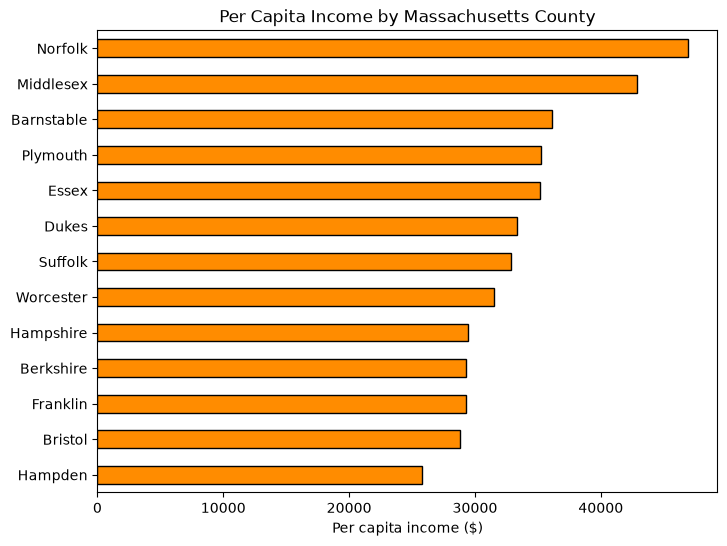

In [15]:
# per capita income by county, sorted - richest at the top
df.sort_values('Per capita income').plot(kind='barh', x='County', y='Per capita income', color='darkorange', edgecolor='black', legend=False, figsize=(8,6))
plt.title('Per Capita Income by Massachusetts County')
plt.xlabel('Per capita income ($)')
plt.ylabel('')
plt.show()

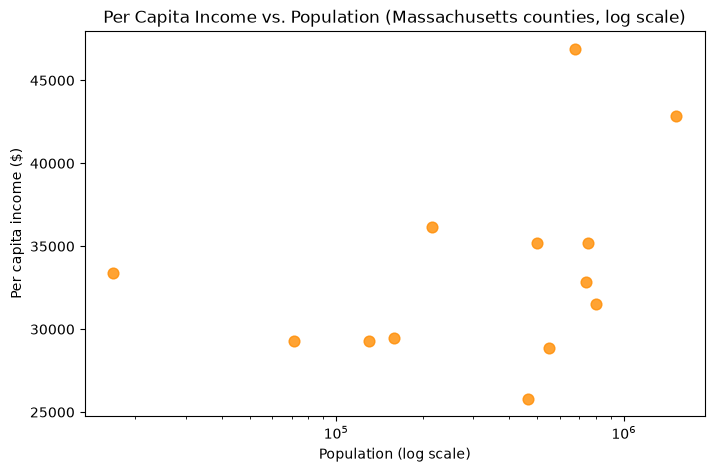

In [16]:
# is income related to population? log scale on x because Middlesex dwarfs Nantucket
df.plot(kind='scatter', x='Population', y='Per capita income', alpha=0.8, s=60, color='darkorange', figsize=(8,5))
plt.xscale('log')
plt.title('Per Capita Income vs. Population (Massachusetts counties, log scale)')
plt.xlabel('Population (log scale)')
plt.ylabel('Per capita income ($)')
plt.show()

## Map it - counties as a choropleth
Geographic data begs for a map. `geopandas` (preinstalled on Colab) reads the Census Bureau's county boundary file straight from a URL; our table merges onto the shapes by county name, and we color each county by each income column.

In [17]:
# download the zip first so GeoPandas does not need remote partial reads
import geopandas as gpd

boundary_response = requests.get('https://www2.census.gov/geo/tiger/GENZ2022/shp/cb_2022_us_county_500k.zip', timeout=180)
boundary_response.raise_for_status()
counties = gpd.read_file(io.BytesIO(boundary_response.content))
print(counties.shape)
counties.head()

(3235, 13)


,STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,geometry
0,01,069,00161560,0500000US01069,01069,Houston,Houston County,AL,Alabama,06,1501742235,4795415,"POLYGON ((-85.71209 31.19727, -85.70934 31.198..."
1,01,023,00161537,0500000US01023,01023,Choctaw,Choctaw County,AL,Alabama,06,2365900083,19114321,"POLYGON ((-88.47323 31.89386, -88.46888 31.930..."
2,01,005,00161528,0500000US01005,01005,Barbour,Barbour County,AL,Alabama,06,2292160151,50523213,"POLYGON ((-85.74803 31.61918, -85.74544 31.618..."
3,01,107,00161580,0500000US01107,01107,Pickens,Pickens County,AL,Alabama,06,2282835044,22621093,"POLYGON ((-88.34043 32.9912, -88.33101 33.0724..."
4,01,033,00161542,0500000US01033,01033,Colbert,Colbert County,AL,Alabama,06,1535742270,79160396,"POLYGON ((-88.13925 34.5878, -88.13872 34.5892..."


Over **3,000 rows** - every county (or county-equivalent) in the United States, one row each, with the polygon stored in the `geometry` column. Before we subset, let's see what states are in here:

In [18]:
# every state name in the shapefile - notice it's more than 50! (DC + territories)
counties['STATE_NAME'].unique()

<ArrowStringArray>
[                                     'Alabama',
                                      'Arizona',
                                     'Arkansas',
                                   'California',
                                     'Colorado',
                                     'Delaware',
                                      'Florida',
                                     'Illinois',
                                      'Georgia',
                                        'Idaho',
                                     'Michigan',
                                      'Indiana',
                                         'Iowa',
                                     'New York',
                                       'Kansas',
                                     'Kentucky',
                                    'Louisiana',
                                        'Maine',
                                       'Alaska',
                                     'Maryland',
 

In [19]:
# subset to Massachusetts - two ways that give the SAME answer:
ma = counties[counties['STATEFP'] == '25']                       # by FIPS code (25 = Massachusetts)
ma_by_name = counties[counties['STATE_NAME'] == 'Massachusetts'] # by state name

print(len(ma), "rows by STATEFP == '25'")
print(len(ma_by_name), "rows by STATE_NAME == 'Massachusetts'")

14 rows by STATEFP == '25'
14 rows by STATE_NAME == 'Massachusetts'


**Remember:** FIPS codes vs. names is a classic data-engineering tradeoff. `STATE_NAME` is human-readable, but one typo ("Massachussets"...) silently returns **zero rows**. `STATEFP` is cryptic but unambiguous - which is exactly why government data ships with code columns. Use the name to explore, the code in production.

In [20]:
# which counties did we get? all 14, by name
ma['NAME'].unique()

<ArrowStringArray>
['Barnstable',    'Hampden',  'Hampshire',    'Suffolk',    'Bristol',
  'Middlesex',  'Worcester',   'Franklin',      'Dukes',      'Essex',
  'Nantucket',   'Plymouth',    'Norfolk',  'Berkshire']
Length: 14, dtype: str

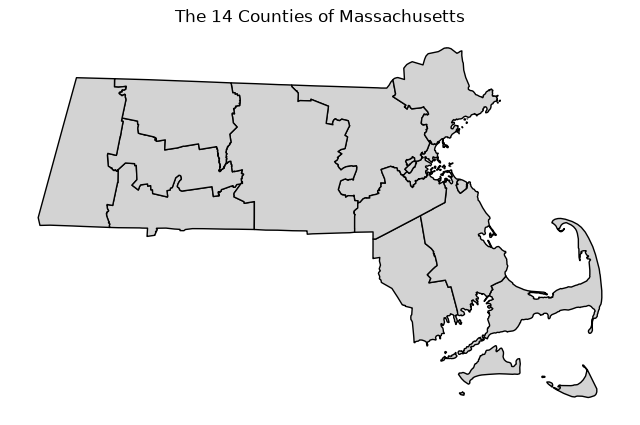

In [21]:
# and here they are on a map
ma.plot(edgecolor='black', color='lightgray', figsize=(8,5))
plt.title('The 14 Counties of Massachusetts')
plt.axis('off')
plt.show()

In [22]:
# join our numbers onto the map - the census NAME column matches our County column
# how='left' keeps every shape, even counties our table is missing
ma_map = ma.merge(df, left_on='NAME', right_on='County', how='left')
ma_map[['NAME'] + money_cols]

,NAME,Per capita income,Median household income,Median family income
0,Barnstable,36142.0,60526.0,76311.0
1,Hampden,25817.0,49094.0,61474.0
2,Hampshire,29460.0,61227.0,81385.0
3,Suffolk,32835.0,53540.0,61449.0
4,Bristol,28837.0,55298.0,72018.0
5,Middlesex,42861.0,82090.0,104032.0
6,Worcester,31537.0,65223.0,81519.0
7,Franklin,29259.0,53663.0,67785.0
8,Dukes,33363.0,66288.0,82452.0
9,Essex,35167.0,67311.0,84185.0


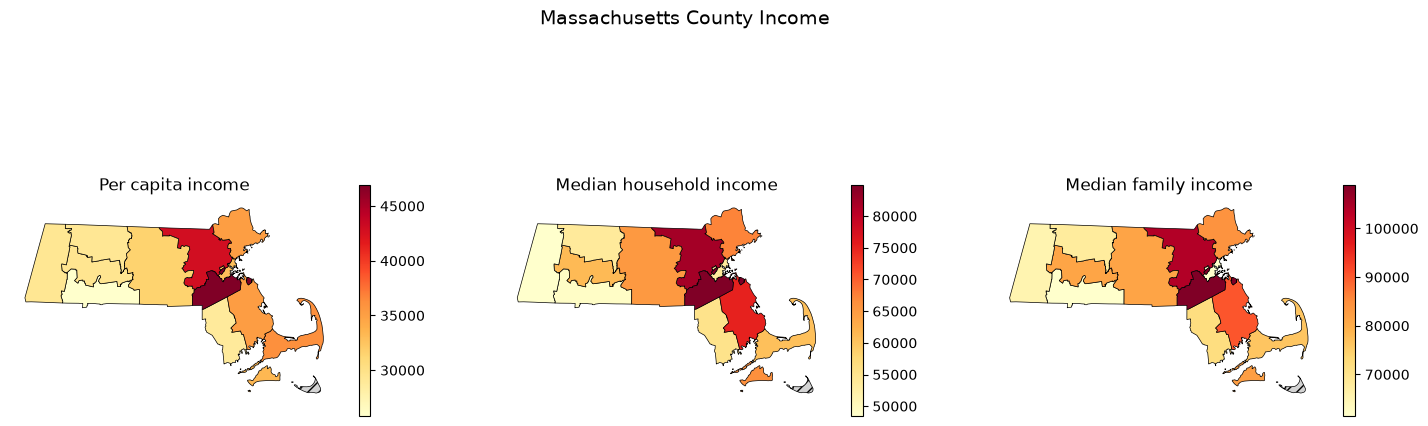

In [23]:
# one map per income column - hatched gray = no data
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, col in zip(axes, money_cols):
    ma_map.plot(column=col, cmap='YlOrRd', legend=True, edgecolor='black', linewidth=0.5, ax=ax,
                legend_kwds={'shrink': 0.5},
                missing_kwds={'color': 'lightgray', 'hatch': '///', 'label': 'no data'})
    ax.set_title(col)
    ax.axis('off')
plt.suptitle('Massachusetts County Income', fontsize=14)
plt.show()

See the hatched county? That's **Nantucket** - one of the wealthiest places in America, and Wikipedia's county table simply doesn't have a row for it. The map made a data-quality problem *visible* that `.describe()` never would have. Always ask what's missing, not just what's there.

**On your own:** confirm it - print the 14 census names (`ma['NAME']`) next to our 13 `df['County']` values and find the gap.

In [24]:
# show both lists and check which name is missing
name_check = pd.DataFrame({
    'Census counties': pd.Series(sorted(ma['NAME'])),
    'Wikipedia counties': pd.Series(sorted(df['County']))
})
display(name_check)
missing_ma = sorted(set(ma['NAME']) - set(df['County']))
print('Missing from Wikipedia:', missing_ma)

,Census counties,Wikipedia counties
0,Barnstable,Barnstable
1,Berkshire,Berkshire
2,Bristol,Bristol
3,Dukes,Dukes
4,Essex,Essex
5,Franklin,Franklin
6,Hampden,Hampden
7,Hampshire,Hampshire
8,Middlesex,Middlesex
9,Nantucket,Norfolk


Missing from Wikipedia: ['Nantucket']


**My answer:** The census has 14 counties, but the Wikipedia table has 13. Nantucket is missing from the Wikipedia county table. I left its income blank because we do not have that value here.

# Step 5: From plot to insight
An insight is one sentence, backed by a number, that a smart non-technical person would care about. Examples of the *form* (check the numbers yourself before quoting them!):

- "Norfolk County's per capita income (~\$47K) is nearly double Hampden County's (~\$26K) - the east/west income split is visible on the map."
- "County population spans two orders of magnitude, so statewide averages are dominated by a handful of big counties."

An **over-claim** looks like: "living near Boston causes higher income." Our data shows association, not causation - we never get to say "cause" from EDA alone.

**On your own:**
1. State ONE insight of your own in a single sentence, backed by a specific number from this notebook.
2. Which income definition changes the county *rankings* the most - per capita, median household, or median family? Why might they disagree?

### My answer 1: One insight

In [25]:
# compare two counties with different population sizes
display(df.set_index('County').loc[['Dukes', 'Hampden'], ['Per capita income', 'Population']])

,Per capita income,Population
County,,
Dukes,33363,16739.0
Hampden,25817,465144.0


Dukes has a higher per capita income than Hampden (\$33,363 vs. \$25,817), even though its population is much smaller (16,739 vs. 465,144).

### My answer 2: Income rankings

In [26]:
# rank 1 means the highest income
income_ranks = df.set_index('County')[money_cols].rank(ascending=False).astype(int)
display(income_ranks)

# compare each pair by adding up the absolute changes in rank
rank_differences = []
for a in range(len(money_cols)):
    for b in range(a + 1, len(money_cols)):
        first, second = money_cols[a], money_cols[b]
        difference = (income_ranks[first] - income_ranks[second]).abs().sum()
        rank_differences.append([first, second, difference])
display(pd.DataFrame(rank_differences, columns=['First measure', 'Second measure', 'Total rank change']))

,Per capita income,Median household income,Median family income
County,,,
Norfolk,1,1,1
Middlesex,2,2,2
Barnstable,3,8,8
Plymouth,4,3,3
Essex,5,4,4
Dukes,6,5,5
Suffolk,7,11,13
Worcester,8,6,6
Hampshire,9,7,7


,First measure,Second measure,Total rank change
0,Per capita income,Median household income,24
1,Per capita income,Median family income,24
2,Median household income,Median family income,4


**My answer:** Per capita income gives the most different ranking. Its total rank change is 24 compared with either of the other two measures. Household and family income only differ by 4. For example, Barnstable is 3rd for per capita income but 8th for both other measures. Per capita income is an average per person, so very high incomes can raise it. Household and family income use medians and count different groups. Household size and the number of earners may also make the rankings different.

## Apply to Connecticut
Same skills, our home state. Everything is counties again: scrape the county table, drop the phantom rows, clean the dollars, map it.

One wrinkle worth 10 seconds: the census **2022** boundary file replaced Connecticut's counties with "planning regions" (yes - Connecticut officially retired its counties!). We just use the **2020** boundary file instead, which still has the 8 legacy counties that Wikipedia reports on.

In [27]:
# scrape the Connecticut page - same User-Agent trick
ct_url = 'https://en.wikipedia.org/wiki/List_of_Connecticut_locations_by_per_capita_income'
ct_response = requests.get(ct_url, headers={'User-Agent': 'Mozilla/5.0 (OPIM 5641 teaching demo)'})
ct_tables = pd.read_html(io.StringIO(ct_response.text))

# table index 1 = Connecticut's county summary table
ct = ct_tables[1]
ct

,Rank,County,Per capita income,Median household income,Median family income,Population,Number of households
0,1.0,Fairfield,"$48,295","$87,268","$109,593",916829.0,335545.0
1,2.0,Litchfield,"$45,848","$79,639","$94,890",189927.0,76640.0
2,3.0,Tolland,"$41,108","$78,175","$89,631",152691.0,54477.0
3,NaN,Connecticut,"$36,775","$67,740","$84,170",3574097.0,1371087.0
4,4.0,Middlesex,"$35,848","$69,639","$84,890",189927.0,76640.0
5,5.0,Hartford,"$33,151","$62,590","$78,599",894014.0,350854.0
6,6.0,New London,"$32,888","$65,419","$80,425",274055.0,107057.0
7,7.0,New Haven,"$31,720","$61,114","$77,379",862477.0,334502.0
8,NaN,United States,"$27,334","$51,914","$62,982",308745538.0,116716292.0
9,8.0,Windham,"$26,585","$59,370","$69,642",118428.0,45724.0


In [28]:
# phantom rows again! drop the blank row, the whole-state row, and the United States row
ct = ct.dropna(subset=['County'])
ct = ct[~ct['County'].isin(['Connecticut', 'United States'])]

# clean the money columns exactly like Massachusetts
for col in money_cols:
    ct[col] = pd.to_numeric(ct[col].astype(str)
                            .str.replace('$', '', regex=False)
                            .str.replace(',', '', regex=False), errors='coerce')
print(len(ct), 'real county rows')
ct[['County'] + money_cols]

8 real county rows


,County,Per capita income,Median household income,Median family income
0,Fairfield,48295,87268,109593
1,Litchfield,45848,79639,94890
2,Tolland,41108,78175,89631
4,Middlesex,35848,69639,84890
5,Hartford,33151,62590,78599
6,New London,32888,65419,80425
7,New Haven,31720,61114,77379
9,Windham,26585,59370,69642


In [29]:
# the 2020 boundary file still has Connecticut's 8 legacy counties
boundary_2020 = requests.get('https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_county_500k.zip', timeout=180)
boundary_2020.raise_for_status()
counties_2020 = gpd.read_file(io.BytesIO(boundary_2020.content))
ct_shapes = counties_2020[counties_2020['STATEFP'] == '09']
ct_shapes['NAME'].unique()

<ArrowStringArray>
[ 'New Haven',  'Middlesex', 'New London',   'Hartford',  'Fairfield',
    'Windham', 'Litchfield',    'Tolland']
Length: 8, dtype: str

8 of 8 counties matched


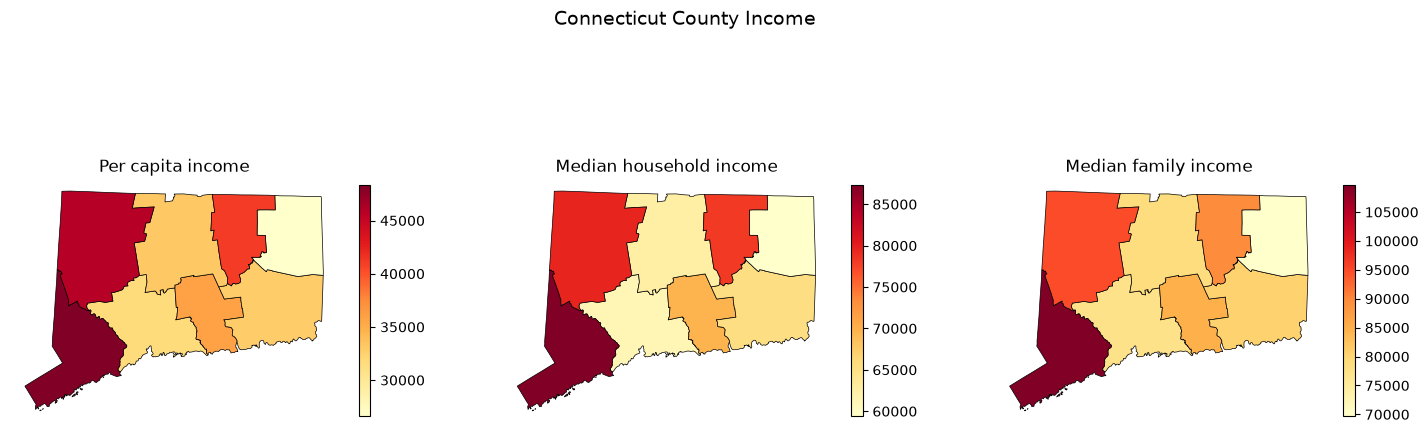

In [30]:
# join and map - how='left' keeps every shape
ct_map = ct_shapes.merge(ct, left_on='NAME', right_on='County', how='left')
print(ct_map[money_cols[0]].notna().sum(), 'of 8 counties matched')   # all 8 or go debug the join keys!

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, col in zip(axes, money_cols):
    ct_map.plot(column=col, cmap='YlOrRd', legend=True, edgecolor='black', linewidth=0.5, ax=ax,
                legend_kwds={'shrink': 0.5},
                missing_kwds={'color': 'lightgray', 'hatch': '///', 'label': 'no data'})
    ax.set_title(col)
    ax.axis('off')
plt.suptitle('Connecticut County Income', fontsize=14)
plt.show()

Fairfield County (Greenwich, Darien, New Canaan) glows just like the Boston suburbs did in Massachusetts, and Windham in the northeast corner tells the other side of the story.

**On your own:** which Connecticut county has the biggest *gap* between median family income and median household income? What might that difference tell you about who lives there?

In [31]:
# family income minus household income for each county
ct_gaps = ct[['County', 'Median household income', 'Median family income']].copy()
ct_gaps['Income gap'] = ct_gaps['Median family income'] - ct_gaps['Median household income']
ct_gaps.sort_values('Income gap', ascending=False)

,County,Median household income,Median family income,Income gap
0,Fairfield,87268,109593,22325
7,New Haven,61114,77379,16265
5,Hartford,62590,78599,16009
1,Litchfield,79639,94890,15251
4,Middlesex,69639,84890,15251
6,New London,65419,80425,15006
2,Tolland,78175,89631,11456
9,Windham,59370,69642,10272


**My answer:** Fairfield has the biggest gap: \$22,325 (\$109,593 minus \$87,268). Family households may have more than one earner, while all households also include people living alone and unrelated people living together. This may help explain the gap, but the table alone cannot prove the reason.

## Scale it with a for loop - six states at once
Here's the payoff: we wrote scrape-and-clean code for one state's county table, so a `for` loop gives us **six states** almost for free - the URL is the only thing that changes.

One honest caveat: the pages aren't *perfectly* identical (the table sits at a different index on some pages), so instead of hard-coding `tables[1]` we make the code **find** the county table on each page: it's the one with a `County` column and a `Per capita income` column that is NOT a town/place listing.

🔷 **The nugget:** a for loop only pays off when the structure repeats. Half the work of scraping at scale is discovering what actually repeats - and writing your code to grab *that*.

In [32]:
# add Maine for the On your own question: seven states
states = ['Connecticut', 'Massachusetts', 'New_Hampshire', 'New_York', 'Vermont', 'Rhode_Island', 'Maine']

original_filter_counts = {} # compare the original filter with the corrected one
state_frames = [] # collect each state's county table here - it survives between iterations!
for state in states:
    # same scrape pattern as before
    state_url = f'https://en.wikipedia.org/wiki/List_of_{state}_locations_by_per_capita_income'
    html = requests.get(state_url, headers={'User-Agent': 'Mozilla/5.0 (OPIM 5641 teaching demo)'}).text

    # hunt for the COUNTY summary table: has County + Per capita income, and is NOT a town/place table
    found = None # reset this so a failed search cannot reuse the last state
    for t in pd.read_html(io.StringIO(html)):
        cols = [str(c) for c in t.columns]
        if 'County' in cols and 'Per capita income' in cols and not any(('Place' in c) or ('Municipality' in c) or ('Type' in c) for c in cols):
            found = t.copy()
            break

    if found is None:
        raise ValueError(f'No county table found for {state}')

    # drop the phantom rows - every state's table hides its own state row + US row
    found = found.dropna(subset=['County'])
    found = found[~found['County'].isin([state.replace('_', ' '), 'United States'])]

    original_filter_counts[state.replace('_', ' ')] = len(found)
    # New York uses a different label for its state summary row
    found = found[~found['County'].isin(['New York State'])].copy()

    # same cleaning as before - strip $ and , then convert
    found['Per capita income'] = pd.to_numeric(found['Per capita income'].astype(str)
                                               .str.replace('$', '', regex=False)
                                               .str.replace(',', '', regex=False), errors='coerce')
    found['State'] = state.replace('_', ' ') # label the rows before stacking
    state_frames.append(found[['State', 'County', 'Per capita income']])

    richest = found.sort_values('Per capita income', ascending=False).iloc[0]
    print(f"{state.replace('_',' '):15s} -> {len(found):3d} counties | richest: {richest['County']}")

# stack all seven into ONE table - possible because we forced the same structure
df_combined = pd.concat(state_frames, ignore_index=True)
df_combined

Connecticut     ->   8 counties | richest: Fairfield


Massachusetts   ->  13 counties | richest: Norfolk


New Hampshire   ->  10 counties | richest: Rockingham


New York        ->  62 counties | richest: New York County


Vermont         ->  14 counties | richest: Chittenden


Rhode Island    ->   5 counties | richest: Newport


Maine           ->  16 counties | richest: Cumberland


,State,County,Per capita income
0,Connecticut,Fairfield,48295
1,Connecticut,Litchfield,45848
2,Connecticut,Tolland,41108
3,Connecticut,Middlesex,35848
4,Connecticut,Hartford,33151
...,...,...,...
123,Maine,Franklin,20838
124,Maine,Somerset,20709
125,Maine,Aroostook,20251
126,Maine,Piscataquis,19870


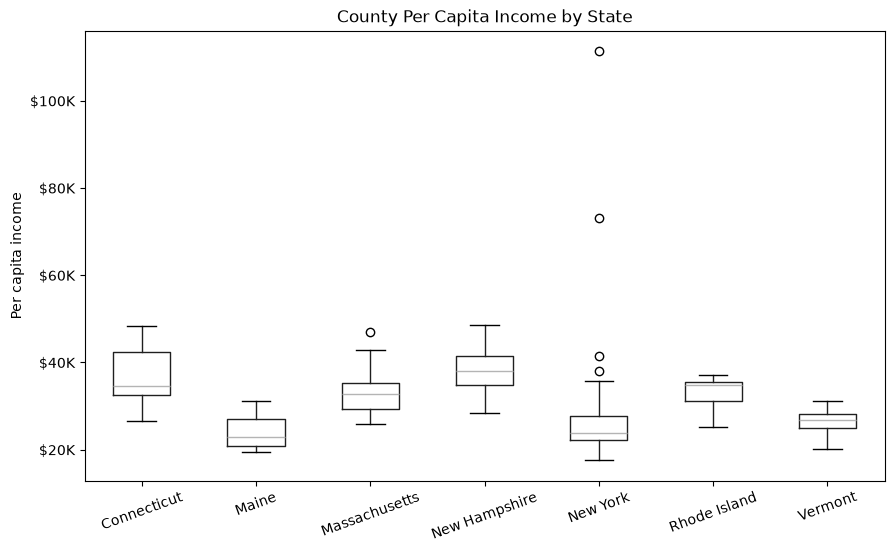

In [33]:
# same structure in, same output out - one boxplot comparing all six states
from matplotlib.ticker import FuncFormatter

df_combined.boxplot(column='Per capita income', by='State', figsize=(10,6), grid=False)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x/1000:.0f}K'))
plt.title('County Per Capita Income by State')
plt.suptitle('') # kill the automatic pandas super-title
plt.xlabel('')
plt.ylabel('Per capita income')
plt.xticks(rotation=20)
plt.show()

So - the loop generated the same output for every state **because we made it so**: we looped over the part that repeats (the county table), taught the code to *find* it, and filtered every state's phantom rows before stacking. That find-what-repeats step is the real skill.

**On your own:**
1. Add **Maine** to the list. Does the table-hunting code survive contact with a seventh page?
2. Trust, but verify: the real county counts are CT 8 · MA 14 · NH 10 · NY 62 · VT 14 · RI 5. Does `df_combined.groupby('State').size()` agree? If a state comes up short (or long!), go inspect its Wikipedia table and figure out who's missing.
3. Swap the boxplot for overlaid histograms. Which tells the income story better?
4. **Your turn to map:** make a county choropleth of per capita income for **each** state. You already have every shape you need - filter `counties` by the state FIPS code (`STATEFP`): CT `'09'` · MA `'25'` · NH `'33'` · NY `'36'` · VT `'50'` · RI `'44'` - then merge that state's rows from `df_combined` on the county name and plot, exactly like we did for Massachusetts. Bonus: wrap it in a for loop, one map per state. *(Remember the Connecticut trick: use `counties_2020` for its shapes.)*

### My answer 1: Add Maine

In [34]:
# Maine was added to the states list in the loop above
maine_data = df_combined[df_combined['State'] == 'Maine']
display(maine_data)
print('Maine county count:', len(maine_data))

,State,County,Per capita income
112,Maine,Cumberland,31041
113,Maine,Lincoln,28003
114,Maine,York,27137
115,Maine,Sagadahoc,26983
116,Maine,Hancock,26876
117,Maine,Knox,25291
118,Maine,Kennebec,24656
119,Maine,Penobscot,22977
120,Maine,Androscoggin,22752
121,Maine,Waldo,22213


Maine county count: 16


**My answer:** Yes, the table search works for Maine. It finds the county table using the same columns. After removing the Maine, United States, and blank rows, there are 16 counties.

### My answer 2: Check the county counts

In [35]:
# compare the original filter, the corrected filter, and the expected counts
expected_counts = pd.Series({
    'Connecticut': 8, 'Massachusetts': 14, 'New Hampshire': 10,
    'New York': 62, 'Vermont': 14, 'Rhode Island': 5, 'Maine': 16
})
county_counts = pd.DataFrame({
    'Expected': expected_counts,
    'Original filter': pd.Series(original_filter_counts),
    'Corrected filter': df_combined.groupby('State').size()
})
display(county_counts)

# use census names to check missing or extra counties, not just totals
state_fips = {'Connecticut': '09', 'Massachusetts': '25', 'New Hampshire': '33',
              'New York': '36', 'Vermont': '50', 'Rhode Island': '44', 'Maine': '23'}
name_checks = []
for state, fips in state_fips.items():
    source_shapes = counties_2020 if state == 'Connecticut' else counties
    shapes = source_shapes[source_shapes['STATEFP'] == fips]
    values = df_combined[df_combined['State'] == state].copy()
    # Wikipedia says New York County; the census name is New York
    values['County'] = values['County'].str.replace(r' County$', '', regex=True).str.strip()
    missing = sorted(set(shapes['NAME']) - set(values['County']))
    extra = sorted(set(values['County']) - set(shapes['NAME']))
    name_checks.append([state, ', '.join(missing) or 'None', ', '.join(extra) or 'None'])
display(pd.DataFrame(name_checks, columns=['State', 'Missing counties', 'Extra names']))

,Expected,Original filter,Corrected filter
Connecticut,8,8,8
Maine,16,16,16
Massachusetts,14,13,13
New Hampshire,10,10,10
New York,62,63,62
Rhode Island,5,5,5
Vermont,14,14,14


,State,Missing counties,Extra names
0,Connecticut,None,None
1,Massachusetts,Nantucket,None
2,New Hampshire,None,None
3,New York,None,None
4,Vermont,None,None
5,Rhode Island,None,None
6,Maine,None,None


**My answer:** The original filter gives 13 counties for Massachusetts and 63 for New York. Massachusetts is missing Nantucket. New York has an extra row called "New York State," which the original filter does not remove. I removed that exact name and kept New York County. Now New York has 62 counties. All other states match the expected counts, including Maine with 16. Massachusetts still has 13 because the missing income should not be made up.

### My answer 3: Overlaid histograms

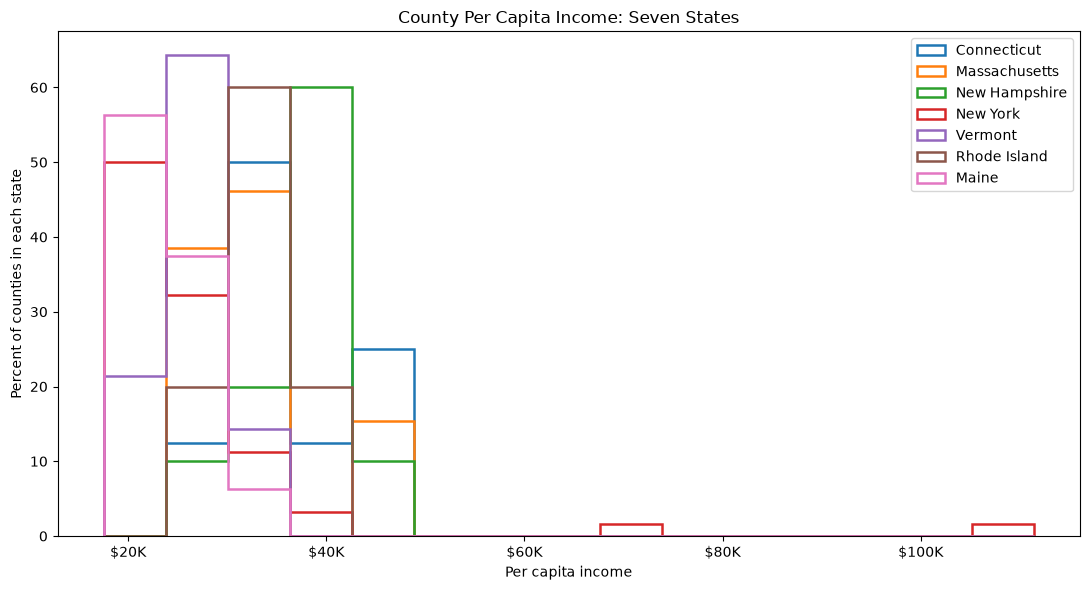

In [36]:
import numpy as np

# use the same bins so the states can be compared
bins = np.linspace(df_combined['Per capita income'].min(),
                   df_combined['Per capita income'].max(), 16)
fig, ax = plt.subplots(figsize=(11, 6))
for state in state_fips:
    incomes = df_combined.loc[df_combined['State'] == state, 'Per capita income'].dropna()
    # percentages avoid giving New York more weight just because it has more counties
    ax.hist(incomes, bins=bins, weights=np.ones(len(incomes)) * 100 / len(incomes),
            histtype='step', linewidth=1.8, label=state)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x/1000:.0f}K'))
ax.set_title('County Per Capita Income: Seven States')
ax.set_xlabel('Per capita income')
ax.set_ylabel('Percent of counties in each state')
ax.legend()
plt.tight_layout()
plt.show()

**My answer:** I think the boxplot tells the story better. It is easier to compare the middle and spread of each state and see the high-income outliers in New York. The histograms show where the values are grouped, but seven overlapping lines are harder to read. Some states also have very few counties.

### My answer 4: County maps for all seven states

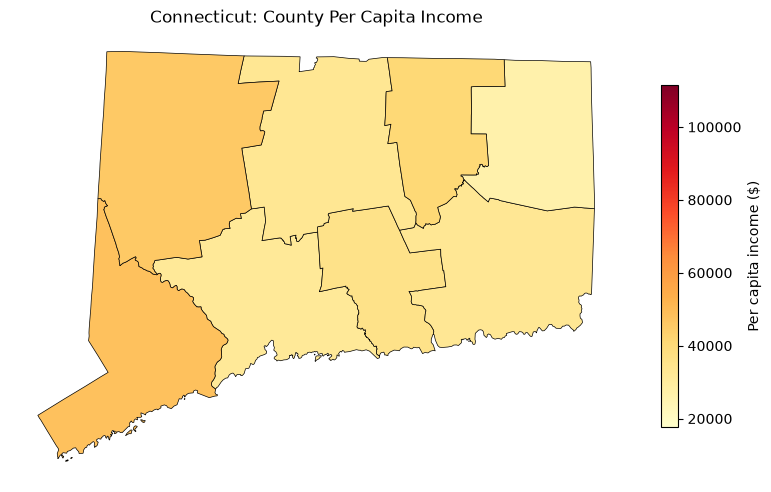

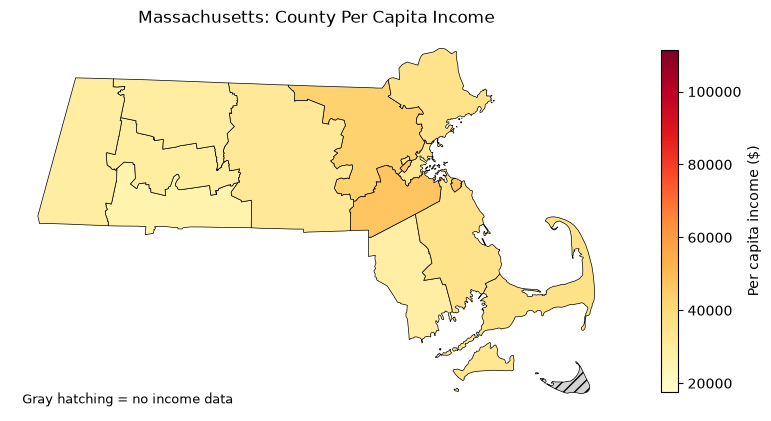

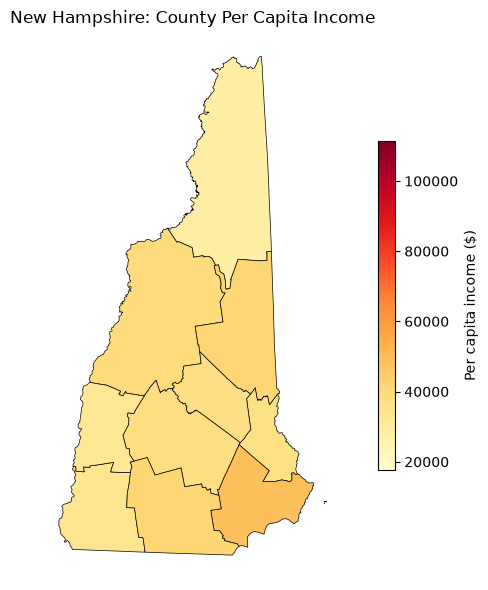

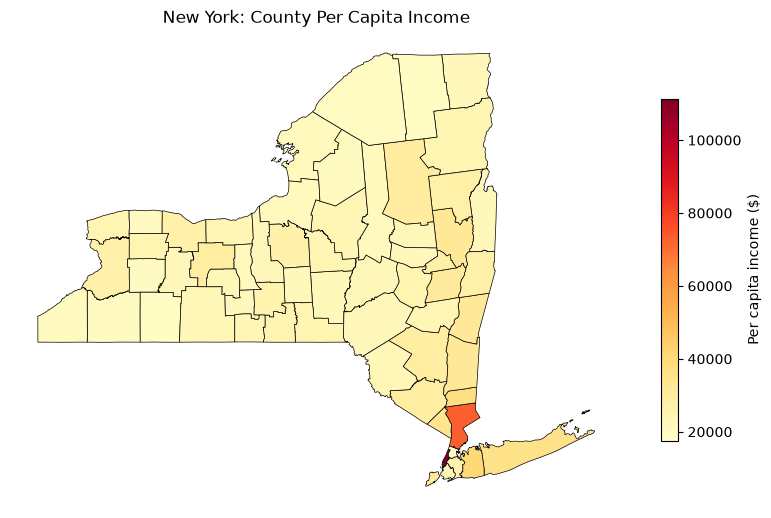

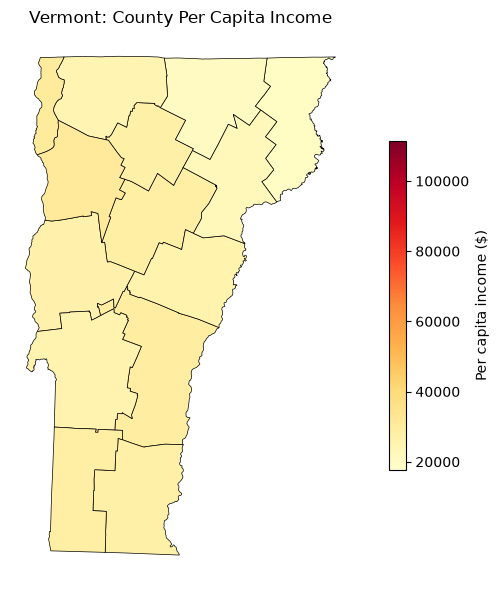

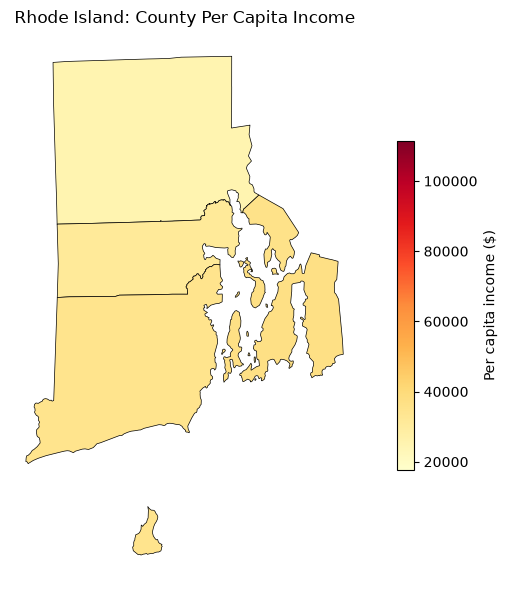

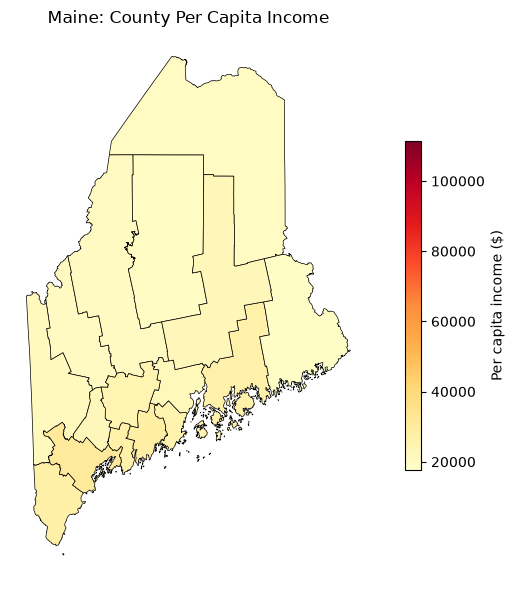

,State,County shapes,Income matches
0,Connecticut,8,8
1,Massachusetts,14,13
2,New Hampshire,10,10
3,New York,62,62
4,Vermont,14,14
5,Rhode Island,5,5
6,Maine,16,16


In [37]:
# use the same color scale for every state
vmin = df_combined['Per capita income'].min()
vmax = df_combined['Per capita income'].max()
map_checks = []

for state, fips in state_fips.items():
    # Connecticut needs the old county boundaries
    source_shapes = counties_2020 if state == 'Connecticut' else counties
    shapes = source_shapes[source_shapes['STATEFP'] == fips].copy()
    values = df_combined[df_combined['State'] == state].copy()
    values['County'] = values['County'].str.replace(r' County$', '', regex=True).str.strip()
    state_map = shapes.merge(values, left_on='NAME', right_on='County',
                             how='left', validate='one_to_one')
    matched = state_map['Per capita income'].notna().sum()
    map_checks.append([state, len(shapes), matched])

    fig, ax = plt.subplots(figsize=(8, 6))
    state_map.plot(column='Per capita income', cmap='YlOrRd', vmin=vmin, vmax=vmax,
                   legend=True, edgecolor='black', linewidth=0.5, ax=ax,
                   legend_kwds={'shrink': 0.6, 'label': 'Per capita income ($)'},
                   missing_kwds={'color': 'lightgray', 'hatch': '///', 'label': 'No data'})
    ax.set_title(f'{state}: County Per Capita Income')
    ax.axis('off')
    if matched < len(shapes):
        ax.text(0.02, 0.02, 'Gray hatching = no income data', transform=ax.transAxes, fontsize=9)
    plt.tight_layout()
    plt.show()

display(pd.DataFrame(map_checks, columns=['State', 'County shapes', 'Income matches']))

**My answer:** I made one map for each state, including Maine. I used the 2020 file for Connecticut and changed "New York County" to "New York" for the map match. Every county matches except Nantucket, which stays gray with hatching. The maps use the same color scale, but the income figures come from different years, so this is not a comparison for one common year.

------------------------------------------------


**Bottom line:** scrape politely (User-Agent header), hunt down the phantom rows before they skew your stats, clean deliberately, map what's geographic - and when the structure repeats, let a for loop do the heavy lifting. Next up: when you have NO data at all... you simulate it. See you in Monte Carlo.